<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>
<center><b><h1>Lab - 5</b></center>
<center><b><h1>Kalp Viradia | 23010101299 | 24/12/2025</b></center>
<pre>    

# SVR

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read World bank CSV

In [2]:
df = pd.read_csv("WorldBank.csv")
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,...,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,...,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [3]:
data = df[df["Indicator Name"] == "Population ages 15-64 (% of total population)"]
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [4]:
X = np.arange(1960, 2020).reshape(-1, 1)
y = data.values[0][4:-1:].reshape(-1, 1)

In [5]:
y

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

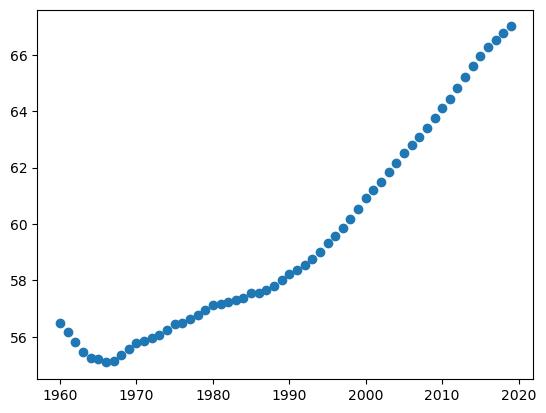

In [6]:
plt.scatter(X, y)

# Splitting the dataset into the Training set and Test set

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [38]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Fitting SVR on 3 Different Kernel on dataset

In [39]:
from sklearn.svm import SVR

model_linear = SVR(kernel = "linear")
print(model_linear.fit(X_scaled, y_scaled.ravel()))

SVR(kernel='linear')


In [40]:
model_poly = SVR(kernel = "poly")
print(model_poly.fit(X_scaled, y_scaled.ravel()))

SVR(kernel='poly')


In [41]:
model_rbf = SVR(kernel = "rbf")
print(model_rbf.fit(X_scaled, y_scaled.ravel()))

SVR()


In [42]:
y_pred_linear = model_linear.predict(X_scaled)
y_pred_linear = y_scaler.inverse_transform(y_pred_linear.reshape(-1, 1))

In [43]:
y_pred_poly = model_poly.predict(X_scaled)
y_pred_poly = y_scaler.inverse_transform(y_pred_poly.reshape(-1, 1))

In [44]:
y_pred_rbf = model_rbf.predict(X_scaled)
y_pred_rbf = y_scaler.inverse_transform(y_pred_rbf.reshape(-1, 1))

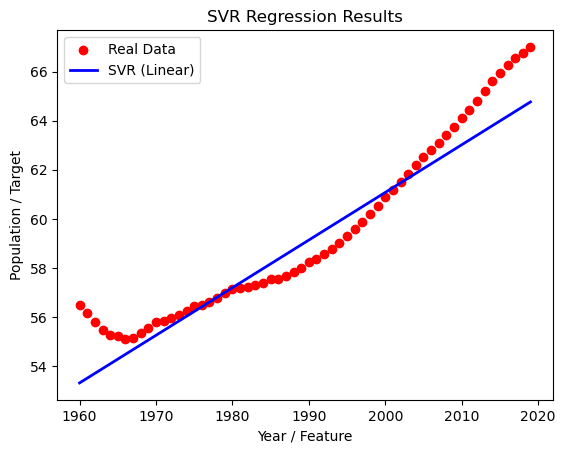

In [45]:
plt.scatter(X, y, color='red', label='Real Data')
plt.plot(X, y_pred_linear, color='blue', linewidth=2, label='SVR (Linear)')
plt.title('SVR Regression Results')
plt.xlabel('Year / Feature')
plt.ylabel('Population / Target')
plt.legend()
plt.show()

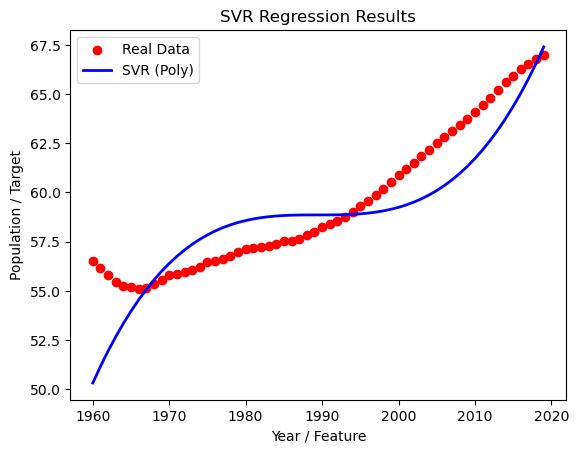

In [46]:
plt.scatter(X, y, color='red', label='Real Data')
plt.plot(X, y_pred_poly, color='blue', linewidth=2, label='SVR (Poly)')
plt.title('SVR Regression Results')
plt.xlabel('Year / Feature')
plt.ylabel('Population / Target')
plt.legend()
plt.show()

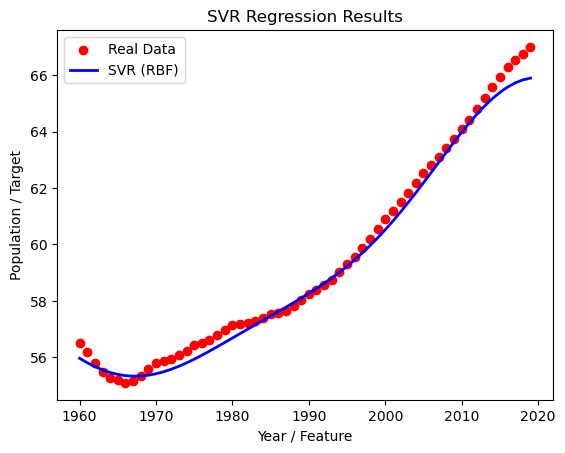

In [47]:
plt.scatter(X, y, color='red', label='Real Data')
plt.plot(X, y_pred_rbf, color='blue', linewidth=2, label='SVR (RBF)')
plt.title('SVR Regression Results')
plt.xlabel('Year / Feature')
plt.ylabel('Population / Target')
plt.legend()
plt.show()

# Predict the x_test using 3 Kernel

In [48]:
from sklearn.svm import SVR

model_linear = SVR(kernel="linear")
model_poly = SVR(kernel="poly")
model_rbf = SVR(kernel="rbf")

print(model_linear.fit(X_train_scaled, y_train_scaled.ravel()))
print(model_poly.fit(X_train_scaled, y_train_scaled.ravel()))
print(model_rbf.fit(X_train_scaled, y_train_scaled.ravel()))

SVR(kernel='linear')
SVR(kernel='poly')
SVR()


In [49]:
y_pred_linear = model_linear.predict(X_test_scaled)
y_pred_poly = model_poly.predict(X_test_scaled)
y_pred_rbf = model_rbf.predict(X_test_scaled)

y_pred_linear = y_scaler.inverse_transform(y_pred_linear.reshape(-1,1))
y_pred_poly = y_scaler.inverse_transform(y_pred_poly.reshape(-1,1))
y_pred_rbf = y_scaler.inverse_transform(y_pred_rbf.reshape(-1,1))

In [50]:
linear_score = model_linear.score(X_test_scaled, y_test_scaled)
poly_score = model_poly.score(X_test_scaled, y_test_scaled)
rbf_score = model_rbf.score(X_test_scaled, y_test_scaled)

print("Linear Kernel R² Score:", linear_score)
print("Polynomial Kernel R² Score:", poly_score)
print("RBF Kernel R² Score:", rbf_score)

Linear Kernel R² Score: 0.8900817841313862
Polynomial Kernel R² Score: 0.6433426853449614
RBF Kernel R² Score: 0.9963214010843326


# Visualising the  results

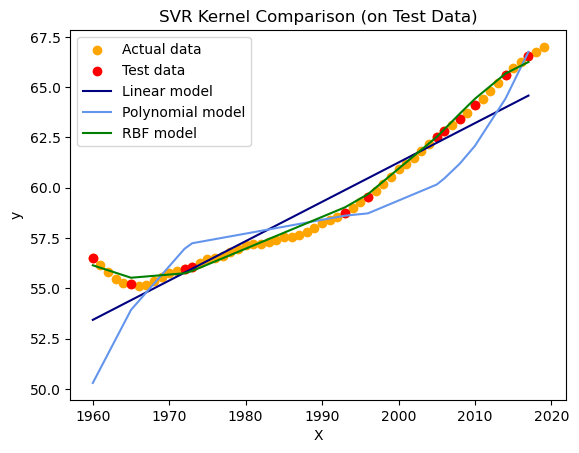

In [53]:
plt.scatter(X, y, color='orange', label='Actual data')

plt.scatter(X_test, y_test, color='red', label='Test data')

sort_idx = X_test[:,0].argsort()
X_test_sorted = X_test[sort_idx]

plt.plot(X_test_sorted, y_pred_linear[sort_idx], color='navy', label='Linear model')
plt.plot(X_test_sorted, y_pred_poly[sort_idx], color='cornflowerblue', label='Polynomial model')
plt.plot(X_test_sorted, y_pred_rbf[sort_idx], color='green', label='RBF model')

plt.title("SVR Kernel Comparison (on Test Data)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

In [54]:
predicted = model_rbf.predict(X_scaler.transform([[2025]]))

In [55]:
print("The predicted value for input 2025 is:", round(y_scaler.inverse_transform(predicted.reshape(-1, 1))[0][0], 2))

The predicted value for input 2025 is: 65.75
